# Activation Function Analysis in Deep Learning

## Overview
This notebook explores the behavior, derivatives, gradient propagation characteristics, computational efficiency, and practical limitations of popular activation functions used in neural networks.

## Objectives
- Implement common activation functions from scratch.
- Visualize activation curves.
- Analyze derivatives.
- Study vanishing gradient behavior.
- Demonstrate the dead neuron problem.
- Compare computational efficiency.
- Explore modern activation functions such as Swish, GELU, and Mish.
- Design and evaluate a custom activation function.

## 1. Implementation of Activation Functions

In [63]:
import numpy as np

In [64]:
def sigmoid_activation_fun(x):
    sigmoid = 1/(1+np.exp(-x))
    return sigmoid
sigmoid_activation_fun(3)

0.9525741268224334

In [65]:
def tanh_activation_fun(x):
    tanh= ((np.exp(x)) - (np.exp(-x))) / ((np.exp(x)) +(np.exp(-x)))
    return tanh
tanh_activation_fun(3)

0.9950547536867306

In [66]:
def relu_activation_fun(x):
    return np.maximum(x,0)

In [67]:
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

## 2. Visualization of Activation Functions

In [68]:
import matplotlib.pyplot as plt

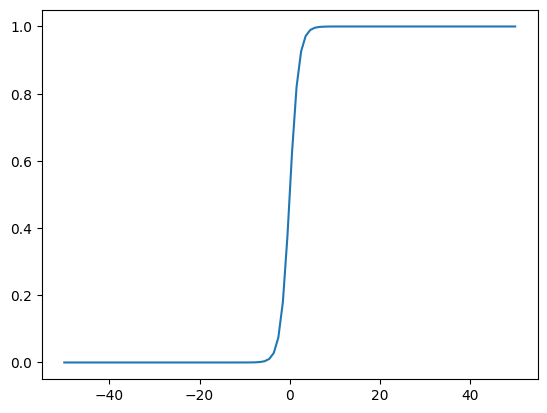

In [69]:
x = np.linspace(-50,50,100)
plt.plot(x,sigmoid_activation_fun(x))

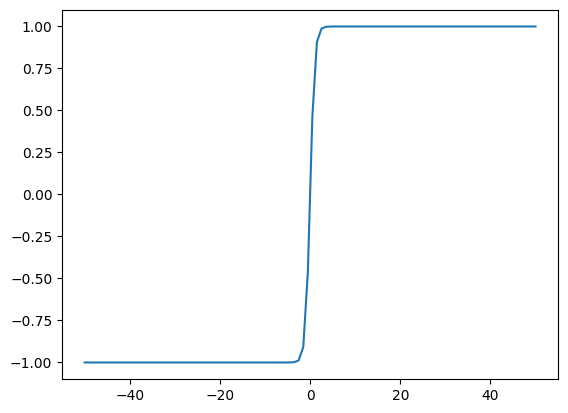

In [70]:
x = np.linspace(-50,50,100)
plt.plot(x,tanh_activation_fun(x))

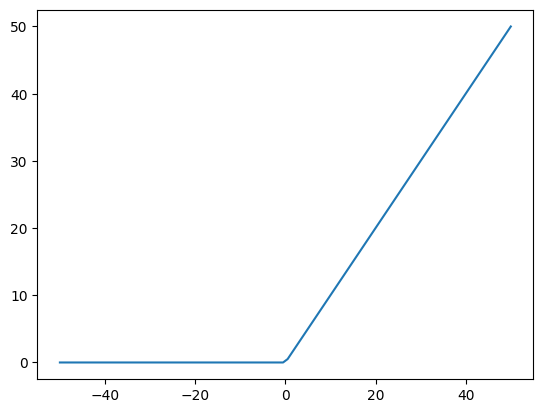

In [71]:
x = np.linspace(-50,50,100)
plt.plot(x,relu_activation_fun(x))

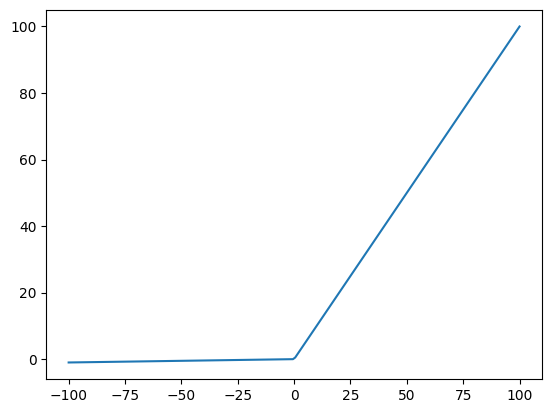

In [72]:
x = np.linspace(-100,100,200)
plt.plot(x,leaky_relu(x))

## 3. Derivative Analysis

In [73]:
def derived_sigmoid_fun(x):
    return sigmoid_activation_fun(x)*( 1 - sigmoid_activation_fun(x))              

In [74]:
def derived_tanh_fun(x):
    return (1 - (tanh_activation_fun(x))**2 )

In [75]:
def derived_relu_fun(x):
    return np.where(x>0 ,1 ,0)

In [76]:
def derived_leaky_relu_fun(x):
    return np.where(x>0 , 1, 0.1)

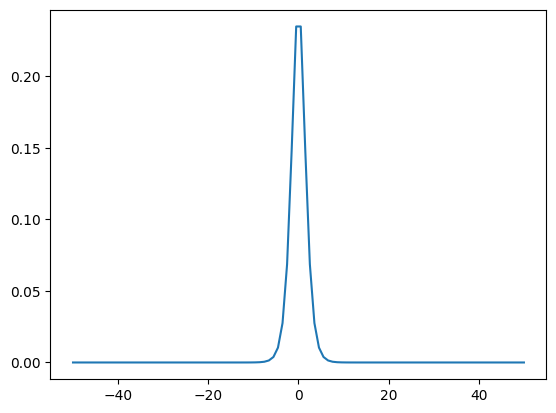

In [77]:
x = np.linspace(-50,50,100)
plt.plot(x,derived_sigmoid_fun(x))

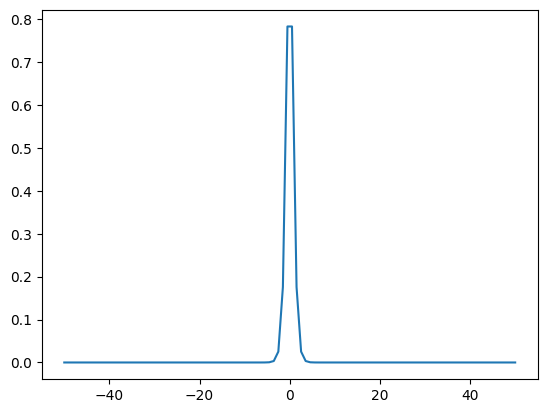

In [78]:
x = np.linspace(-50,50,100)
plt.plot(x,derived_tanh_fun(x))

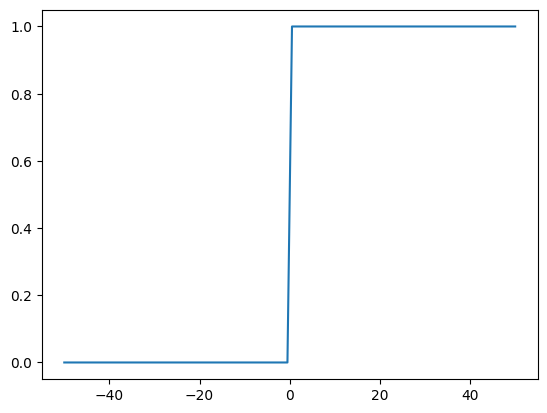

In [79]:
x = np.linspace(-50,50,100)
plt.plot(x,derived_relu_fun(x))

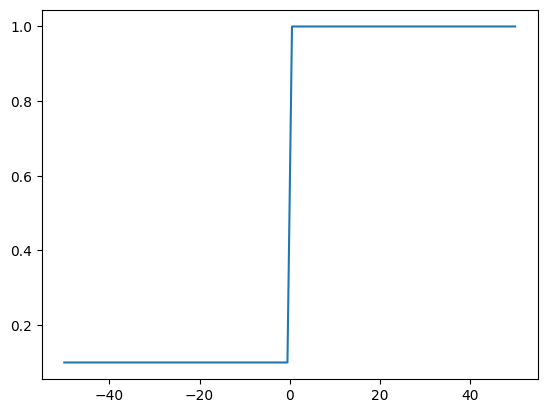

In [80]:
x = np.linspace(-50,50,100)
plt.plot(x,derived_leaky_relu_fun(x))

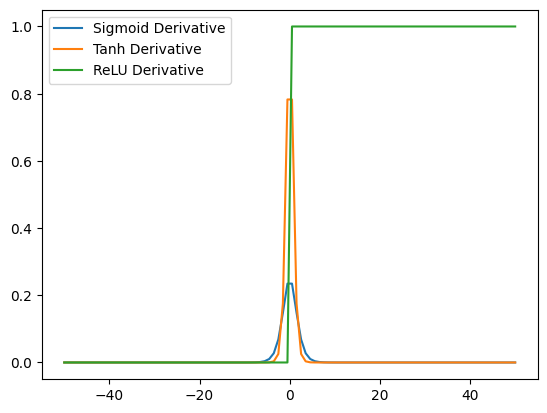

In [81]:
plt.plot(x, derived_sigmoid_fun(x), label="Sigmoid Derivative")
plt.plot(x, derived_tanh_fun(x), label="Tanh Derivative")
plt.plot(x, derived_relu_fun(x), label="ReLU Derivative")
plt.legend()
plt.show()

## 4. Observational Analysis

The activation function plots reveal significant differences in how neural networks process information. The Sigmoid function produces outputs between 0 and 1, making it suitable for probability estimation. However, it saturates for large positive and negative inputs, causing gradients to become extremely small. The Tanh function exhibits a similar saturation effect but is zero-centered, which can improve optimization during training.

The ReLU activation function generates zero output for negative inputs and increases linearly for positive inputs. This behavior reduces the vanishing gradient problem and enables faster convergence compared to Sigmoid and Tanh. However, neurons can become permanently inactive when they consistently receive negative inputs, resulting in the dead neuron problem.

Leaky ReLU addresses this limitation by allowing a small non-zero gradient for negative inputs. As a result, neurons continue learning even when receiving negative values. The derivative plots further confirm that ReLU and Leaky ReLU maintain stronger gradients than Sigmoid and Tanh across a wider input range.

Analysis of the derivative curves shows that Sigmoid derivatives approach zero rapidly as inputs move away from the origin, leading to vanishing gradients in deep neural networks. Tanh exhibits a similar trend but maintains slightly larger gradients near zero. ReLU and Leaky ReLU preserve gradient flow more effectively, making them more suitable for deep learning applications.

Overall, the observations indicate that modern activation functions such as ReLU and Leaky ReLU provide better gradient propagation, faster training, and improved scalability compared to traditional Sigmoid and Tanh functions.


## 5. Vanishing Gradient Experiment

In [82]:
def sigmoid_vanishing_gradient(layers,x):
    gradients = []
    gradient = 1
    for i in range(layers):
        gradient *= derived_sigmoid_fun(x)
        gradients.append(gradient)
    return gradients
sigmoid_vanishing_gradient(50,0.23)

[0.24672268314386264,
 0.060872082377706846,
 0.015018523492782071,
 0.0037054104129983284,
 0.0009142087992441558,
 0.00022555604790324698,
 5.564979333801471e-05,
 1.3730066328756441e-05,
 3.3875188043739928e-06,
 8.35777728615441e-07,
 2.0620532371588468e-07,
 5.0875530745731844e-08,
 1.255214745195504e-08,
 3.0968994985637462e-09,
 7.640753537125303e-10,
 1.8851472139205138e-10,
 4.6510857873964636e-11,
 1.1475283649987407e-11,
 2.8312127719617906e-12,
 6.985244116495859e-13,
 1.7234181708367385e-13,
 4.25206355287728e-14,
 1.049080528664108e-14,
 2.5883196286599063e-15,
 6.385971636168982e-16,
 1.5755640565562138e-16,
 3.8872739149857764e-17,
 9.590786504204382e-18,
 2.3662645797772517e-18,
 5.838111461509282e-19,
 1.4403945242765073e-19,
 3.553780018152275e-20,
 8.767981413815742e-21,
 2.1632599001721382e-21,
 5.337252869079944e-22,
 1.316821348476683e-22,
 3.248896963172866e-23,
 8.015765760119565e-24,
 1.9776712357894028e-24,
 4.879363536704001e-25,
 1.2038496638099382e-25,
 2.

In [83]:
def tanh_vanishing_gradient(layers,x):
    gradient = 1
    gradients = []
    for i in range(layers):
        gradient *= derived_tanh_fun(x)
        gradients.append(gradient)
    return gradients
tanh_vanishing_gradient(50,0.23)

[0.948911183966189,
 0.9004324350561146,
 0.8544304080306563,
 0.810778570101084,
 0.7693568528890334,
 0.7300513221674338,
 0.6927538644739814,
 0.6573618897351585,
 0.6237780490828406,
 0.5919099670873179,
 0.5616699876702148,
 0.5329749329984184,
 0.5057458746958294,
 0.47990791674363537,
 0.4553899894719503,
 0.4321246540761787,
 0.4100479171204066,
 0.3890990545175948,
 0.3692204445024156,
 0.3503574091373098,
 0.3324580639158111,
 0.31547317504945926,
 0.2993560240457552,
 0.2840622792046685,
 0.26954987368023614,
 0.25577888977184954,
 0.2427114491269631,
 0.230311608553216,
 0.21854526115338965,
 0.20738004251126294,
 0.19678524167032113,
 0.18673171666045707,
 0.17719181434031325,
 0.1681392943347838,
 0.15954925685845925,
 0.15139807422648616,
 0.14366332586445593,
 0.13632373663856132,
 0.12935911833639216,
 0.12275031413740824,
 0.11647914592034968,
 0.1105283642626495,
 0.10488160099431695,
 0.09952332417578673,
 0.09443879537589663,
 0.08961402913248272,
 0.08503575448408

In [84]:
def relu_vanishing_gradient(layers,x):
    gradient = 1
    gradients=[]
    for i in range(layers):
        gradient *= derived_relu_fun(x)
        gradients.append(gradient)
    return gradients
relu_vanishing_gradient(50,0.23)

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

In [85]:
def leaky_relu_vanishing_gradient(layers,x):
    gradient = 1
    gradients=[]
    for i in range(layers):
        gradient *= derived_leaky_relu_fun(x)
        gradients.append(gradient)
    return gradients
leaky_relu_vanishing_gradient(50,0.23)

[1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

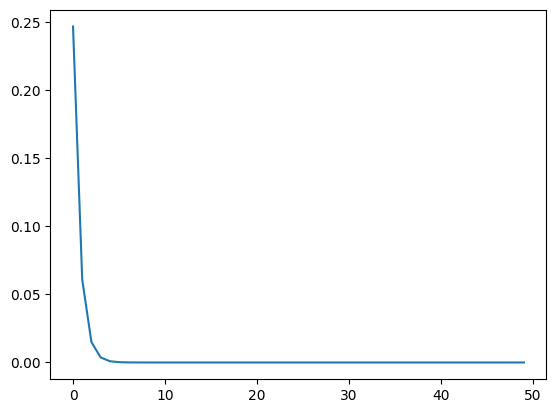

In [86]:
layers = np.arange(50)
gradients = sigmoid_vanishing_gradient(50, 0.23)
plt.plot(layers,gradients)

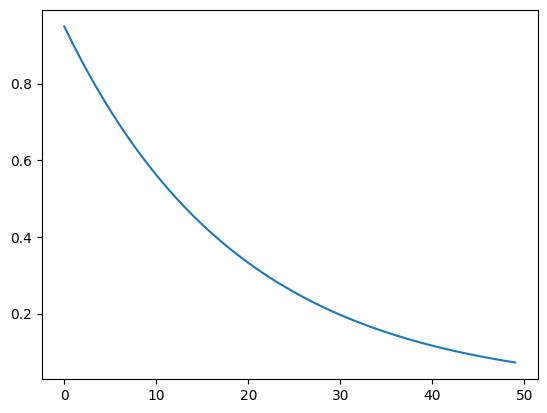

In [87]:
layers = np.arange(50)
gradients = tanh_vanishing_gradient(50, 0.23)
plt.plot(layers,gradients)

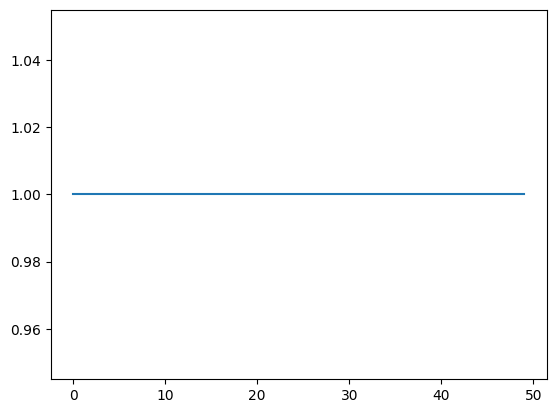

In [88]:
layers = np.arange(50)
gradients = relu_vanishing_gradient(50, 0.23)
plt.plot(layers,gradients)

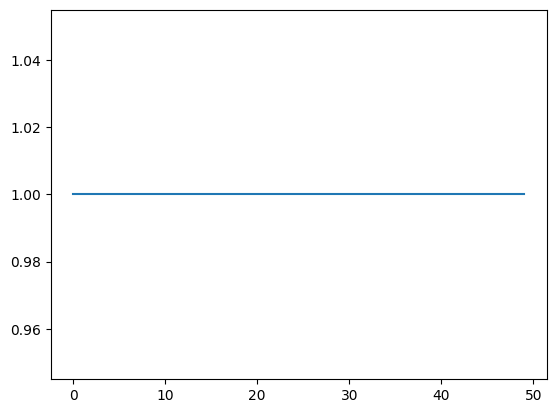

In [89]:
layers = np.arange(50)
gradients = leaky_relu_vanishing_gradient(50, 0.23)
plt.plot(layers,gradients)

## 6. Dead Neuron Experiment

In [ ]:
x = np.linspace(-5,5,100)
w = -0.2
b = -3
z = np.dot(w,x) + b
z

array([-2.        , -2.02020202, -2.04040404, -2.06060606, -2.08080808,
       -2.1010101 , -2.12121212, -2.14141414, -2.16161616, -2.18181818,
       -2.2020202 , -2.22222222, -2.24242424, -2.26262626, -2.28282828,
       -2.3030303 , -2.32323232, -2.34343434, -2.36363636, -2.38383838,
       -2.4040404 , -2.42424242, -2.44444444, -2.46464646, -2.48484848,
       -2.50505051, -2.52525253, -2.54545455, -2.56565657, -2.58585859,
       -2.60606061, -2.62626263, -2.64646465, -2.66666667, -2.68686869,
       -2.70707071, -2.72727273, -2.74747475, -2.76767677, -2.78787879,
       -2.80808081, -2.82828283, -2.84848485, -2.86868687, -2.88888889,
       -2.90909091, -2.92929293, -2.94949495, -2.96969697, -2.98989899,
       -3.01010101, -3.03030303, -3.05050505, -3.07070707, -3.09090909,
       -3.11111111, -3.13131313, -3.15151515, -3.17171717, -3.19191919,
       -3.21212121, -3.23232323, -3.25252525, -3.27272727, -3.29292929,
       -3.31313131, -3.33333333, -3.35353535, -3.37373737, -3.39

In [91]:
y = relu_activation_fun(z)

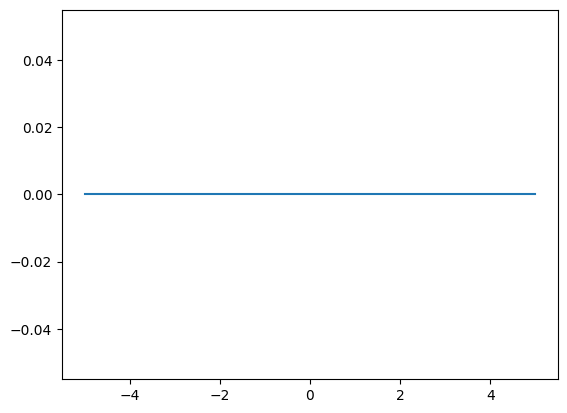

In [92]:
plt.plot(x,y)

In [93]:
y2 = leaky_relu(z)

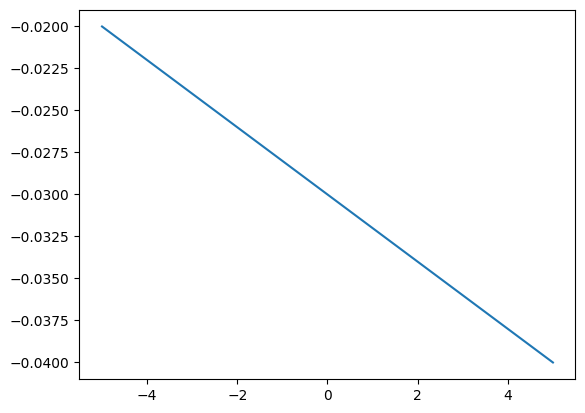

In [94]:
plt.plot(x,y2)

## 7. Output Distribution Analysis

(array([ 74., 222., 352., 403., 495., 450., 395., 322., 226.,  61.]),
 array([0.02067767, 0.11587415, 0.21107062, 0.30626709, 0.40146357,
        0.49666004, 0.59185652, 0.68705299, 0.78224947, 0.87744594,
        0.97264241]),
 <BarContainer object of 10 artists>)

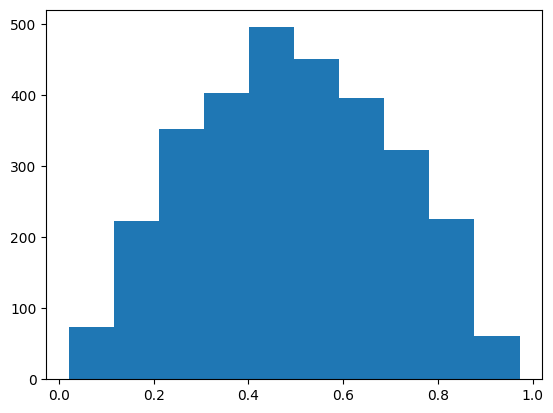

In [95]:
x = np.random.randn(3000)
y = sigmoid_activation_fun(x)
plt.hist(y)

In [96]:
np.mean(y)

0.4921317428245115

In [97]:
np.std(y)

0.20745739876363192

(array([423., 322., 286., 286., 241., 256., 226., 265., 302., 393.]),
 array([-9.99108773e-01, -7.99355997e-01, -5.99603221e-01, -3.99850445e-01,
        -2.00097669e-01, -3.44893382e-04,  1.99407883e-01,  3.99160658e-01,
         5.98913434e-01,  7.98666210e-01,  9.98418986e-01]),
 <BarContainer object of 10 artists>)

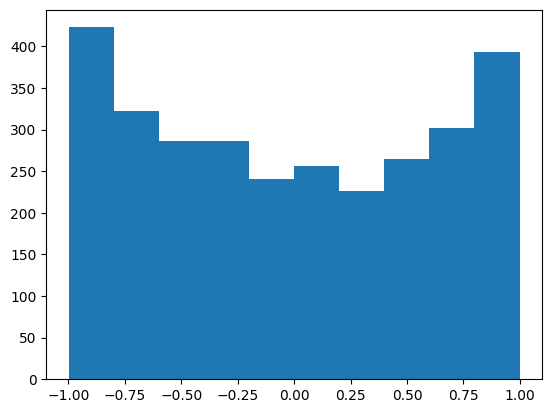

In [98]:
y = tanh_activation_fun(x)
plt.hist(y)

In [99]:
np.mean(y)

-0.024173570737103873

In [100]:
np.std(y)

0.6239930462245353

(array([1976.,  346.,  271.,  183.,  125.,   59.,   18.,   12.,    6.,
           4.]),
 array([0.        , 0.35710227, 0.71420454, 1.0713068 , 1.42840907,
        1.78551134, 2.14261361, 2.49971588, 2.85681814, 3.21392041,
        3.57102268]),
 <BarContainer object of 10 artists>)

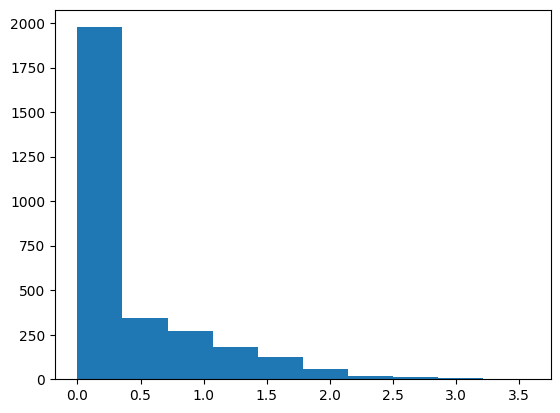

In [101]:
y = relu_activation_fun(x)
plt.hist(y)

In [102]:
np.mean(y == 0) ## Relu

0.5196666666666667

In [103]:
np.std(y)

0.5766586876619096

(array([1940.,  359.,  284.,  185.,  130.,   59.,   21.,   12.,    6.,
           4.]),
 array([-0.03857806,  0.32238201,  0.68334208,  1.04430216,  1.40526223,
         1.76622231,  2.12718238,  2.48814246,  2.84910253,  3.21006261,
         3.57102268]),
 <BarContainer object of 10 artists>)

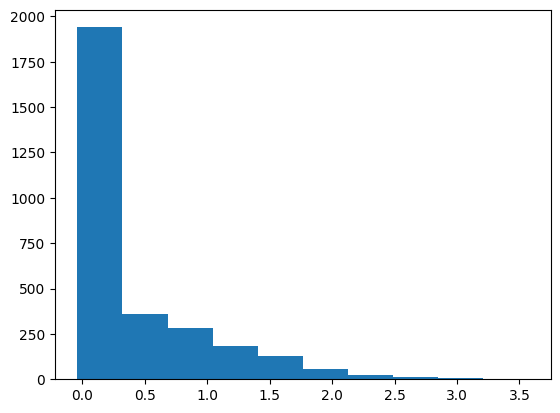

In [104]:
y = leaky_relu(x)
plt.hist(y)

In [105]:
np.mean(y)

0.3737758824957979

In [106]:
np.std(y)

0.5794050761712438

## 8. Computational Efficiency Benchmark

In [107]:
x = np.random.randn(1000000)

In [108]:
import time

In [109]:
start_time = time.perf_counter()
sigmoid_activation_fun(x)
end_time = time.perf_counter()
execution_time = end_time -start_time
execution_time

0.019231899990700185

In [110]:
start_time = time.perf_counter()
tanh_activation_fun(x)
end_time = time.perf_counter()
execution_time = end_time -start_time
execution_time

0.05491170007735491

In [111]:
start_time = time.perf_counter()
relu_activation_fun(x)
end_time = time.perf_counter()
execution_time = end_time -start_time
execution_time

0.0038264000322669744

In [112]:
start_time = time.perf_counter()
leaky_relu(x)
end_time = time.perf_counter()
execution_time = end_time -start_time
execution_time

0.008346900111064315

## 9. Modern Activation Functions

In [113]:
def swish_fun(x,b):
    return x*sigmoid_activation_fun(b*x)

In [114]:
def gelu_fun(x):
    gelu = 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))
    return gelu

In [115]:
def mish_fun(x):
    mish = x*np.tanh(np.log(1+np.exp(x)))
    return mish

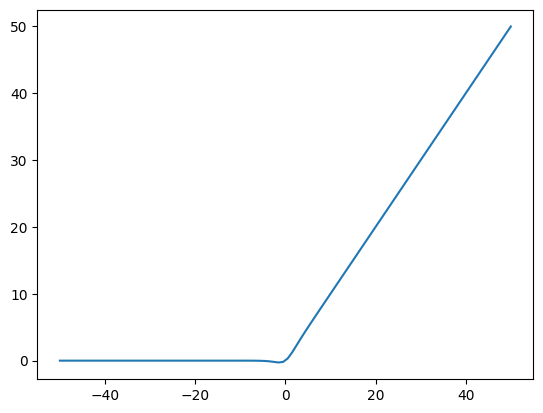

In [116]:
x = np.linspace(-50,50,100)
plt.plot(x,swish_fun(x,1))

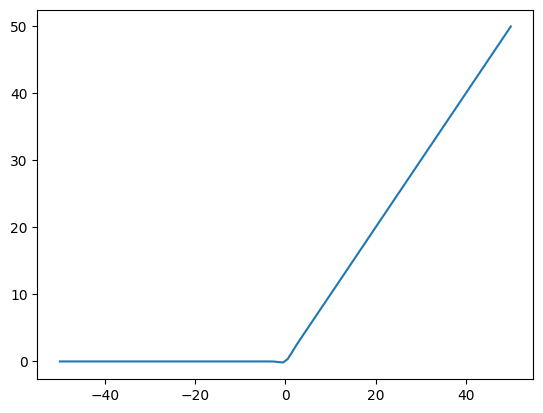

In [117]:
x = np.linspace(-50,50,100)
plt.plot(x, gelu_fun(x))

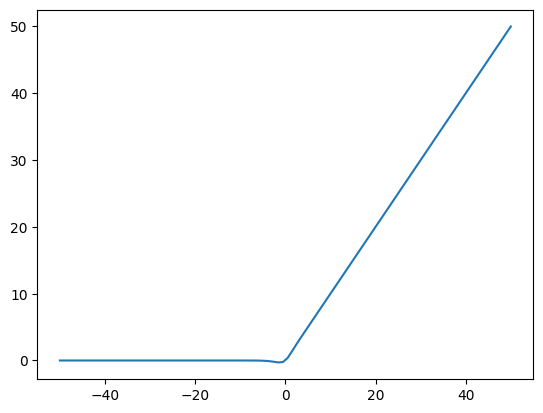

In [118]:
x = np.linspace(-50,50,100)
plt.plot(x,mish_fun(x))

In [119]:
x = np.random.randn(1000000)
start_time = time.perf_counter()
swish_fun(x,1)
end_time = time.perf_counter()
execution_time = end_time -start_time
execution_time

0.02114079997409135

In [120]:
start_time = time.perf_counter()
gelu_fun(x)
end_time = time.perf_counter()
execution_time = end_time -start_time
execution_time

0.06305570004042238

In [121]:
start_time = time.perf_counter()
mish_fun(x)
end_time = time.perf_counter()
execution_time = end_time -start_time
execution_time

0.04205069993622601

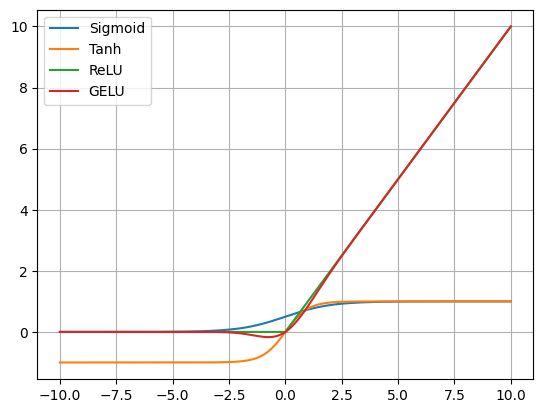

In [122]:
x = np.linspace(-10,10,1000)
plt.plot(x, sigmoid_activation_fun(x), label="Sigmoid")
plt.plot(x, tanh_activation_fun(x), label="Tanh")
plt.plot(x, relu_activation_fun(x), label="ReLU")
plt.plot(x, gelu_fun(x), label="GELU")
plt.legend()
plt.grid()
plt.show()

## 10. Custom Activation Function

In [123]:
## experimental exploration
def custom_activation_function(x):
    return np.log(1 +np.maximum(0,x))

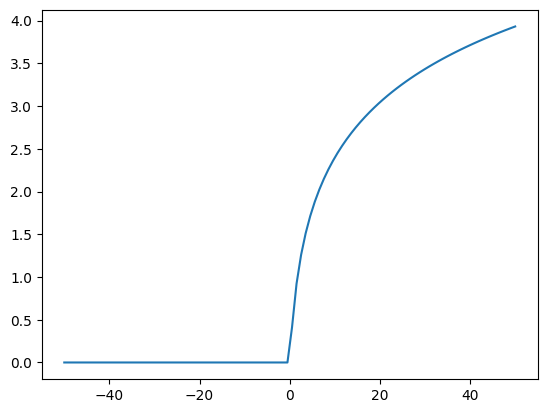

In [126]:
x = np.linspace(-50,50,100)
plt.plot(x,custom_activation_function(x))

In [127]:
x = np.random.randn(1000000)
start_time = time.perf_counter()
custom_activation_function(x)
end_time = time.perf_counter()
execution_time = end_time -start_time
execution_time

0.026395399938337505

The custom logarithmic-ReLU-inspired activation compresses large positive activations while preserving ReLU-like sparsity in negative regions. However, the logarithmic computation introduces additional computational overhead compared to standard ReLU.

In [133]:
def derived_custom_fun(x):
    return np.where(x<0,0,1/(1+x))

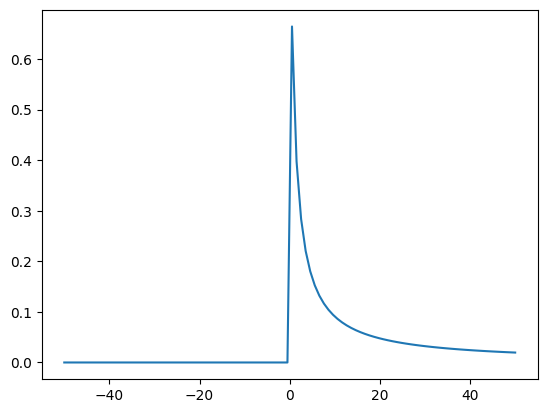

In [134]:
x = np.linspace(-50,50,100)
plt.plot(x,derived_custom_fun(x))

## Observations

- Strong gradients were observed for small positive inputs, enabling effective local learning.
- Logarithmic compression reduced activation growth for large positive values.
- Output compression helped reduce activation explosion risk in deeper layers.
- Positive-region gradients decayed smoothly instead of abruptly saturating.
- Negative inputs produced zero gradients due to the ReLU component.
- The dead neuron problem still persisted for consistently negative activations.

## Tradeoffs

| Property | Behavior |
|---|---|
| Small-value learning | Strong |
| Large-value stability | Improved |
| Computational cost | Higher than ReLU |
| Sparsity | Preserved |
| Dead neuron issue | Present |

## Possible Improvement

A more stable variant can be constructed using:

$$
f(x)=\log(1+\mathrm{LeakyReLU}(x))
$$

### Expected Improvements

- Prevents complete gradient collapse in the negative region.
- Reduces dead neuron probability.
- Preserves logarithmic compression behavior.
- Maintains smoother gradient flow for negative inputs.
- Retains activation stabilization for large positive values.

### Expected Tradeoff

- Slight increase in computational complexity due to logarithmic operations.
- Reduced sparsity compared to standard ReLU.

# Conclusion

This study compared classical and modern activation functions used in deep learning.

Key findings:

- Sigmoid suffers from severe vanishing gradients.
- Tanh provides better zero-centered outputs but still experiences gradient decay.
- ReLU is computationally efficient and remains the default choice for many architectures.
- Leaky ReLU mitigates the dead neuron problem.
- Swish, GELU, and Mish provide smoother gradients and improved learning dynamics.
- The proposed custom logarithmic activation compresses large activations while maintaining computational simplicity.

Overall, ReLU remains the fastest activation, while GELU and Swish offer stronger performance for modern deep learning architectures.